# The Tully-Fisher Relation and Deming Regression

*Tutorial by Yuan-Sen Ting (ting.74@osu.edu)*

*Companion material for Chapter 6 of the textbook*

*If you find this tutorial useful, please cite the accompanying textbook:*

*[Statistical Machine Learning for Astronomy](https://arxiv.org/abs/2506.12230)*

*© 2025 Yuan-Sen Ting. All rights reserved. This tutorial may be redistributed by sharing the original [GitHub repository link](https://github.com/tingyuansen/statml) for educational purposes. Any other reproduction or adaptation requires explicit permission from the author.*

## Introduction

In our exploration of linear regression, we developed techniques for modeling relationships between variables while accounting for uncertainties in the dependent variable. We demonstrated that when the dependent variable $x$ has measurement errors, we can properly handle them through weighted least squares or Bayesian inference. But what happens when the independent variable $x$ also carries measurement uncertainties?

The Tully-Fisher relation provides an astronomical laboratory to explore this question. This scaling law connects a galaxy's rotation velocity to its total baryonic mass (stars plus gas). It serves as both a cosmic distance indicator and a probe of galaxy formation physics. Yet both quantities—rotation velocities from spectroscopic observations and masses from photometric measurements—carry uncertainties.

When we apply standard regression techniques that ignore uncertainties in the independent variable, something troubling happens. The measurement errors in velocity cause the observed distribution of velocities to appear wider than the true distribution. Think of it this way: if every galaxy's measured velocity includes random noise, the cloud of points spreads out horizontally on our plot. This artificial widening doesn't affect the vertical spread correspondingly, so the relationship appears shallower than it truly is.

This systematic underestimation of the slope is called **attenuation bias** or **regression dilution**. The word "attenuation" means weakening—measurement uncertainties literally weaken the observed relationship. This isn't a random error that averages out with more data. Even with infinite galaxies, if we ignore velocity uncertainties, we will systematically underestimate the Tully-Fisher slope by a predictable amount.

In this tutorial, we'll use real galaxy data from the SPARC (Spitzer Photometry and Accurate Rotation Curves) survey ([Lelli et al. 2016](https://ui.adsabs.harvard.edu/abs/2016AJ....152..157L/abstract)) to demonstrate attenuation bias in action. We'll derive the mathematical form of this bias, showing that it depends on the ratio of measurement uncertainty to the intrinsic spread in the data. We'll implement Deming regression—a technique that treats the true velocities as latent variables to be inferred alongside the slope—allowing us to recover the unbiased Tully-Fisher relation that standard methods miss.

## Prerequisites and Learning Objectives

### Foundational Knowledge

This tutorial assumes familiarity with:
- **Python Programming**: NumPy arrays, matplotlib visualization, pandas DataFrames, and scipy optimization
- **Linear Regression**: Understanding of maximum likelihood estimation, residuals, and goodness-of-fit metrics
- **Probability Theory**: Normal distributions, maximum likelihood estimation, and error propagation
- **Linear Algebra**: Matrix operations and solving linear systems

### Learning Outcomes

Through this tutorial, you will develop practical skills in:
- **Identifying Attenuation Bias**: Recognizing when measurement uncertainties in independent variables compromise standard regression
- **Implementing Deming Regression**: Building both analytical and numerical solutions for regression with errors in both variables
- **Quantifying Bias**: Calculating the attenuation factor and predicting its magnitude from measurement uncertainties
- **Handling Heteroscedastic Errors**: Extending methods to cases where uncertainties vary across observations
- **Astronomical Applications**: Applying these techniques to real galaxy data and interpreting scaling relations

We begin by importing the necessary libraries and loading the SPARC galaxy dataset, which provides high-quality rotation curves and photometry for nearby galaxies:

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.optimize import brentq

# Configure plotting for publication quality
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 2

# Set random seed for reproducibility
np.random.seed(42)

## The SPARC Galaxy Dataset

The SPARC (Spitzer Photometry and Accurate Rotation Curves) database provides a laboratory for studying the Tully-Fisher relation. SPARC contains 175 disk galaxies with new surface photometry at 3.6 μm from the Spitzer Space Telescope and high-quality rotation curves from previous HI/Hα studies.

The dataset spans a broad range of galaxy properties: morphologies from S0 to irregular, luminosities covering ~5 orders of magnitude, surface brightnesses spanning ~4 orders of magnitude, rotation velocities from ~20 to ~300 km/s, and gas fractions varying by three orders of magnitude. This diversity ensures we're not studying a biased subset of galaxies but rather sampling the full range of systems where the Tully-Fisher relation applies.

The 3.6 μm Spitzer observations are particularly valuable for our purposes. Near-infrared photometry provides a good proxy for stellar mass distributions, as it minimizes the effects of internal dust extinction and recent star formation. This gives us reliable estimates of the baryonic mass—the sum of stellar and gas masses—which forms the dependent variable in our Tully-Fisher analysis.

For this tutorial, we've extracted four key quantities from SPARC:
- `logV`: The logarithm of the rotation velocity in km/s
- `e_logV`: The measurement uncertainty in `logV`
- `log_M_b`: The logarithm of the baryonic mass in solar masses
- `e_log_M_b`: The measurement uncertainty in `log_M_b`

These logarithmic quantities are natural for the Tully-Fisher relation, which exhibits a power-law relationship between velocity and mass. 

The measurement uncertainties arise from different sources. Velocity measurements face several challenges: disk inclination uncertainties become very large for face-on galaxies, non-circular motions may not trace the gravitational potential exactly, and the inclination angle can vary with radius in warped disks. In contrast, the 3.6 μm mass estimates are relatively precise thanks to Spitzer's photometry and the weak dependence of near-infrared mass-to-light ratios on stellar populations.

As we'll see in the data, velocity uncertainties in SPARC are typically larger than mass uncertainties. This makes the Tully-Fisher relation an interesting case where the independent variable (velocity) often has larger uncertainties than the dependent variable (mass)—highlighting why proper treatment of $x$-uncertainties through Deming regression is essential.

In [29]:
# Load the prepared SPARC dataset
data = np.load('dataset_tully_fisher.npz')
logV = data['logV']
e_logV = data['e_logV']
log_M_b = data['log_M_b']
e_log_M_b = data['e_log_M_b']

print(f"Dataset contains {len(logV)} galaxies")
print(f"Median velocity uncertainty: {np.median(e_logV):.3f} dex")
print(f"Median mass uncertainty: {np.median(e_log_M_b):.3f} dex")

Dataset contains 85 galaxies
Median velocity uncertainty: 0.016 dex
Median mass uncertainty: 0.003 dex


## Visualizing the Tully-Fisher Relation

The Tully-Fisher relation states that a galaxy's rotation velocity $V$ is related to its baryonic mass $M_b$ through a power law:

$$M_b \propto V^\alpha$$

where empirical studies typically find $\alpha \approx 3-4$. This power-law relationship emerges from the virial theorem and the dynamics of rotating disks. For a galaxy in dynamical equilibrium, the rotation velocity at a given radius depends on the enclosed mass. When we consider the characteristic velocity and total mass, a power-law scaling naturally arises. Further, when we take the logarithm of both sides, the power law becomes linear:

$$\log(M_b) = \alpha \log(V) + \beta$$

Let's examine the Tully-Fisher relation in our data and visualize how measurement uncertainties affect both variables:

/var/folders/vl/t6d3ts5x1ys22p56k2_nj1h80000gn/T/ipykernel_61804/1165853567.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


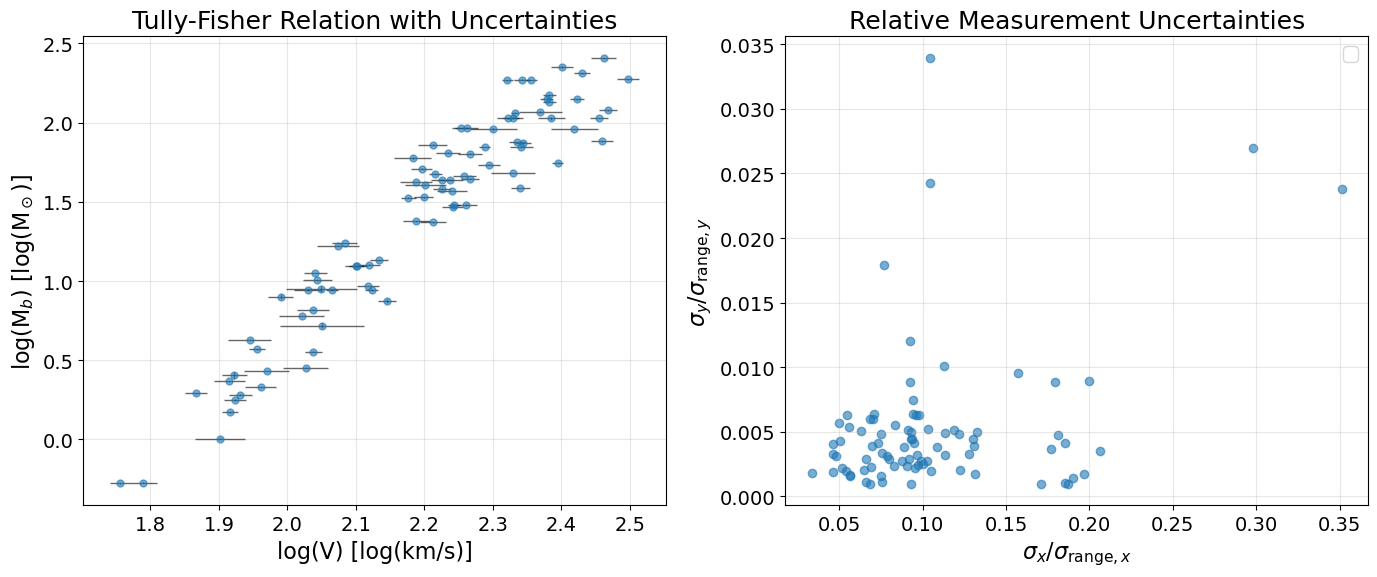


Median relative uncertainties:
X-axis (velocity): 9.3%
Y-axis (mass): 0.4%


In [30]:
# Visualize the Tully-Fisher relation with uncertainties
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Data with error bars
ax1.errorbar(logV, log_M_b, 
             xerr=e_logV, yerr=e_log_M_b,
             fmt='o', markersize=5, alpha=0.6, 
             ecolor='black', elinewidth=1, capsize=0)
ax1.set_xlabel('log(V) [log(km/s)]')
ax1.set_ylabel('log(M$_b$) [log(M$_\odot$)]')
ax1.set_title('Tully-Fisher Relation with Uncertainties')
ax1.grid(True, alpha=0.3)

# Right panel: Distribution of relative errors
ax2.scatter(e_logV/np.std(logV), 
            e_log_M_b/np.std(log_M_b), 
            alpha=0.6)
ax2.set_xlabel('$\sigma_x / \sigma_{\\text{range},x}$')
ax2.set_ylabel('$\sigma_y / \sigma_{\\text{range},y}$')
ax2.set_title('Relative Measurement Uncertainties')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate median relative errors
median_rel_x = np.median(e_logV) / np.std(logV)
median_rel_y = np.median(e_log_M_b) / np.std(log_M_b)
print(f"\nMedian relative uncertainties:")
print(f"X-axis (velocity): {median_rel_x:.1%}")
print(f"Y-axis (mass): {median_rel_y:.1%}")

The right panel shows that measurement uncertainties are not symmetric between the two variables. With velocity uncertainties at ~10% of the data range and mass uncertainties at only ~0.5%, we have a situation where the independent variable carries substantially more uncertainty than the dependent variable. This asymmetry has important consequences:

1. **Standard regression assumes perfect $x$-measurements**: Maximum likelihood estimation (MLE) treats the independent variable as known exactly. With 10% relative uncertainty in velocity, this assumption is clearly violated.

2. **The 10% threshold matters**: Our velocity uncertainties are approaching the 10% level where attenuation bias becomes notable. As we'll demonstrate, this level of uncertainty can bias our slope estimates by several percent.


## Demonstrating Attenuation Bias

To understand how measurement uncertainties affect regression, let's create a controlled simulation. We'll generate data from a known linear relationship, add realistic measurement errors, and observe how standard regression underestimates the true slope.

In our simulation, we start with true data points generated from $x_{\text{true}} = \beta x_{\text{true}}$ with $\beta = 3$—this is our ground truth. We then add Gaussian noise to both $x$ and $x$ coordinates to simulate measurement errors, just as real astronomical observations contain uncertainties. When we fit a line to these noisy observations using the maximum likelihood estimator (MLE), we can directly compare the fitted slope to the true slope we started with.

As we saw in previous chapters, the MLE for linear regression with homoscedastic Gaussian noise minimizes the sum of squared residuals. This derivation assumes the independent variable $x$ is known exactly and only $x$ contains measurement error. When these assumptions hold, the MLE recovers the true parameters. But when $x$ has measurement errors, we're treating noisy $x$-values as if they were the true values, and the MLE systematically underestimates the slope.

From the theoretical derivation, we showed that when measurement errors are present in $x$, the expected value of the MLE slope estimate becomes:

$$\mathbb{E}[\hat{\beta}] = \beta \cdot \lambda$$

where the attenuation factor is:

$$\lambda = \frac{1}{1 + (\sigma_x/\sigma_{\text{range}})^2}$$

Here, $\sigma_x$ is the measurement uncertainty in $x$ and $\sigma_{\text{range}}$ is the intrinsic spread (standard deviation) of the true $x$ values. This result comes from recognizing that measurement uncertainties inflate the observed variance in $x$ from $\sigma_{\text{range}}^2$ to $\sigma_{\text{range}}^2 + \sigma_x^2$, while leaving the covariance between $x$ and $x$ unchanged. The ratio of these quantities gives us the attenuated slope. We'll now demonstrate this theoretical prediction with three different levels of $x$-uncertainty:

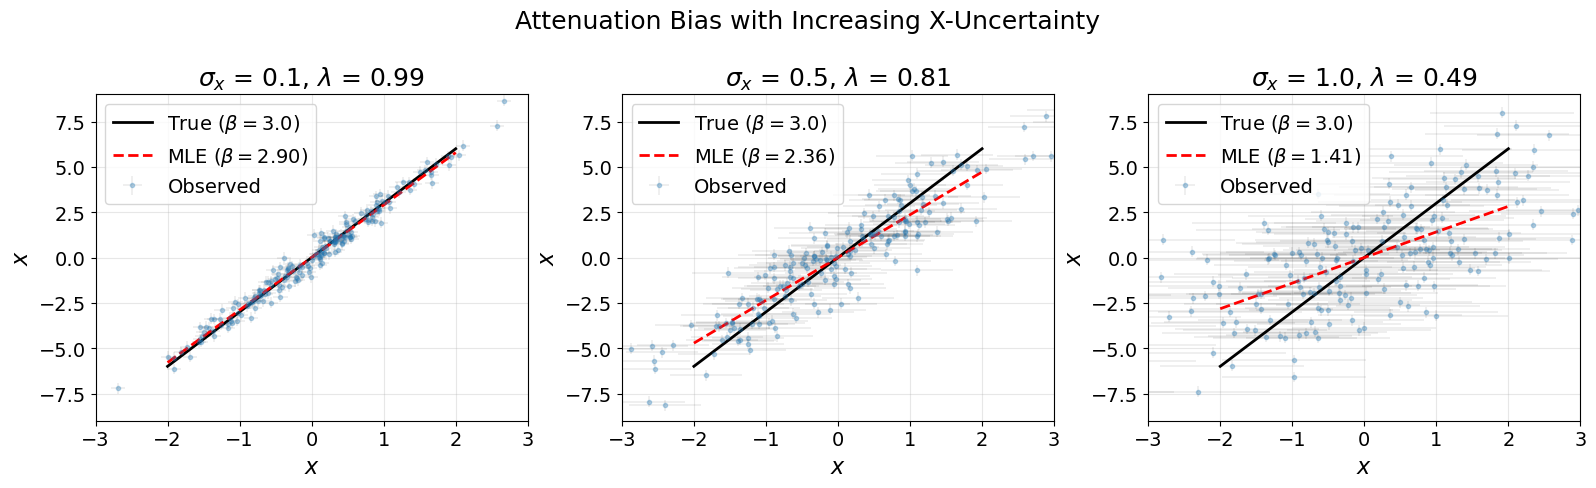

In [31]:
# Run simulation with different error levels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Set parameters
n_points = 200
true_slope = 3.0
sigma_y = 0.3
x_range = 2.0
sigma_x_values = [0.1, 0.5, 1.0]

for ax, sigma_x in zip(axes, sigma_x_values):
    # Generate true values
    x_true = np.random.normal(0, x_range/2, n_points)
    y_true = true_slope * x_true
    
    # Add measurement errors
    x_obs = x_true + np.random.normal(0, sigma_x, n_points)
    y_obs = y_true + np.random.normal(0, sigma_y, n_points)
    
    # Center the observed data
    x_obs = x_obs - np.mean(x_obs)
    y_obs = y_obs - np.mean(y_obs)
    
    # MLE for slope (assumes no x-uncertainty)
    slope_mle = np.sum(x_obs * y_obs) / np.sum(x_obs**2)
    
    # Calculate theoretical attenuation factor
    sigma_range = np.std(x_true)
    lambda_theory = 1 / (1 + (sigma_x/sigma_range)**2)
    
    # Plot data and fits with error bars
    ax.errorbar(x_obs, y_obs, xerr=sigma_x, yerr=sigma_y, fmt='o', 
                alpha=0.3, markersize=3, capsize=0, elinewidth=0.3,
                label='Observed', ecolor='black')
    
    x_line = np.linspace(-2, 2, 100)
    ax.plot(x_line, true_slope * x_line, 'k-', 
            label=f'True ($\\beta={true_slope:.1f}$)')
    ax.plot(x_line, slope_mle * x_line, 'r--', 
            label=f'MLE ($\\beta={slope_mle:.2f}$)')
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$x$')
    ax.set_title(f'$\sigma_x$ = {sigma_x:.1f}, $\lambda$ = {lambda_theory:.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-9, 9)

plt.suptitle('Attenuation Bias with Increasing X-Uncertainty', fontsize=18)
plt.tight_layout()
plt.show()

The simulation clearly demonstrates attenuation bias in action. As measurement uncertainty in $x$ increases, the MLE slope increasingly underestimates the true relationship. The attenuation factor $\lambda$ quantifies this bias—when $\sigma_x$ equals the data range, we recover only half the true slope ($\lambda \approx 0.5$).

This isn't a small-sample issue that would disappear with more data. Even with infinite observations, measurement uncertainties in $x$ cause the observed distribution to appear wider than the true distribution, systematically weakening any relationship we measure. The bias depends only on the ratio $\sigma_x/\sigma_{\text{range}}$, not on sample size.

## Understanding the Attenuation Factor

The attenuation factor provides a quantitative measure of bias:

$$\lambda = \frac{1}{1 + (\sigma_x/\sigma_{\text{range}})^2}$$

This formula reveals that bias depends not on absolute measurement errors but on their size relative to the intrinsic data spread. Let's visualize this relationship:

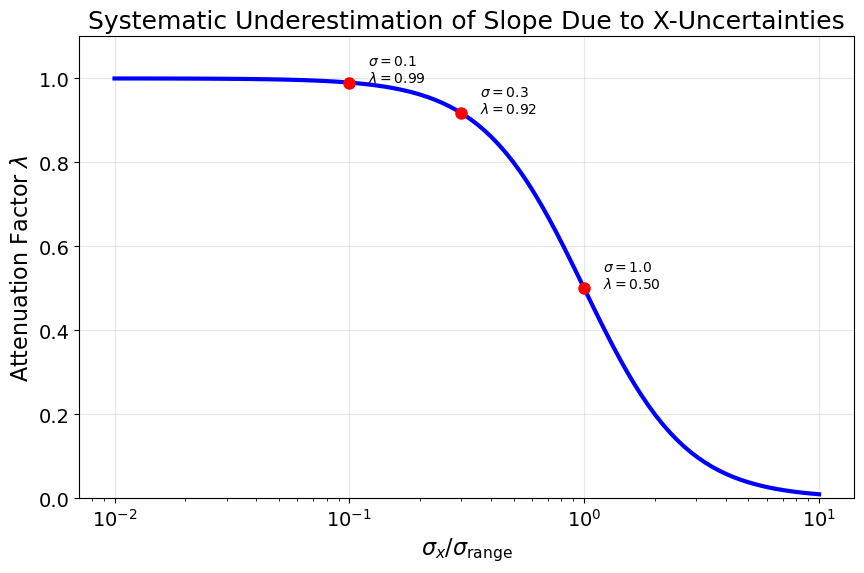

In [32]:
# Create theoretical attenuation curve
sigma_ratio = np.logspace(-2, 1, 100)
lambda_values = 1 / (1 + sigma_ratio**2)

plt.figure(figsize=(10, 6))
plt.semilogx(sigma_ratio, lambda_values, 'b-', linewidth=3)
plt.xlabel('$\sigma_x / \sigma_{\\text{range}}$')
plt.ylabel('Attenuation Factor $\lambda$')
plt.title('Systematic Underestimation of Slope Due to X-Uncertainties')
plt.grid(True, alpha=0.3)

# Mark key points on the curve
key_points = [0.1, 0.3, 1.0]
for point in key_points:
    lambda_point = 1 / (1 + point**2)
    plt.plot(point, lambda_point, 'ro', markersize=8)
    plt.text(point*1.2, lambda_point, f'$\sigma={point:.1f}$\n$\lambda={lambda_point:.2f}$', 
             fontsize=10, ha='left')

plt.ylim(0, 1.1)
plt.show()

## The Asymmetry of Measurement Uncertainties

The attenuation curve shows that only uncertainties in the independent variable cause attenuation bias. To understand this asymmetry, recall that the MLE minimizes squared residuals in the $x$-direction. When $x$ has measurement errors, these simply add to the residual variance, which the MLE already accounts for. But when $x$ has errors, we're using incorrect $x$-values to predict $x$, systematically weakening the observed relationship.

We can demonstrate this asymmetry by comparing scenarios with only $x$-uncertainties versus only $x$-uncertainties:

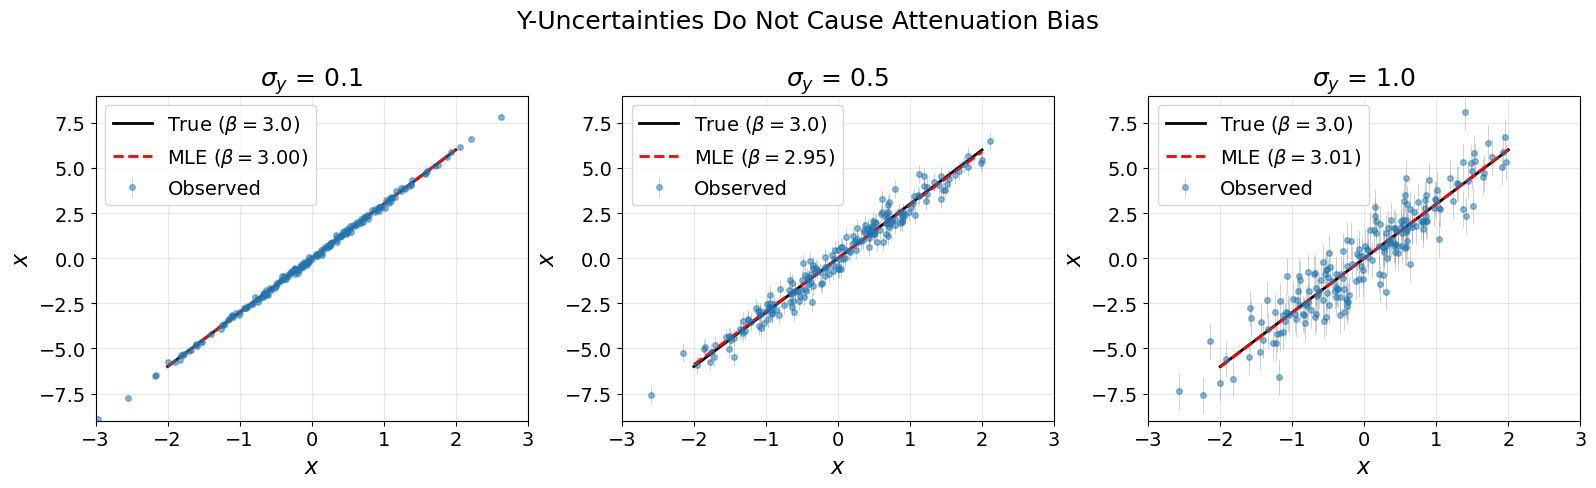

In [33]:
# Demonstrate that y-uncertainties don't cause attenuation bias
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Set parameters
n_points = 200
true_slope = 3.0
x_range = 2.0
sigma_y_values = [0.1, 0.5, 1.0]

for ax, sigma_y in zip(axes, sigma_y_values):
    # Generate true values
    x_true = np.random.normal(0, x_range/2, n_points)
    y_true = true_slope * x_true
    
    # Add measurement errors (only in y)
    x_obs = x_true.copy()
    y_obs = y_true + np.random.normal(0, sigma_y, n_points)
    
    # Center the observed data
    x_obs = x_obs - np.mean(x_obs)
    y_obs = y_obs - np.mean(y_obs)
    
    # MLE for slope
    slope_mle = np.sum(x_obs * y_obs) / np.sum(x_obs**2)
    
    # Plot data with y-error bars
    ax.errorbar(x_obs, y_obs, yerr=sigma_y, fmt='o', markersize=4, 
                alpha=0.5, ecolor='gray', elinewidth=0.5, capsize=0,
                label='Observed')
    
    x_line = np.linspace(-2, 2, 100)
    ax.plot(x_line, true_slope * x_line, 'k-', 
            label=f'True ($\\beta={true_slope:.1f}$)')
    ax.plot(x_line, slope_mle * x_line, 'r--', 
            label=f'MLE ($\\beta={slope_mle:.2f}$)')
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$x$')
    ax.set_title(f'$\sigma_y$ = {sigma_y:.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-9, 9)

plt.suptitle('Y-Uncertainties Do Not Cause Attenuation Bias', fontsize=18)
plt.tight_layout()
plt.show()

The comparison is striking—even with large $x$-uncertainties ($\sigma_y = 1.0$), the MLE recovers the true slope almost perfectly. The error bars show the measurement uncertainty in $x$, yet the fitted slope remains unbiased. This contrasts sharply with our earlier demonstration where $x$-uncertainties of the same magnitude caused severe attenuation.

This asymmetry arises from how regression works. The MLE finds the line that minimizes squared vertical distances (residuals) from the data points. When $x$ has measurement errors, these errors simply increase the scatter around the true line, but the best-fit line still passes through the center of the cloud. The MLE correctly handles this by estimating both the slope and the residual variance. However, when $x$ has measurement errors, we're measuring distances from the wrong $x$-positions, leading to systematic underestimation of the slope.

## Implementing Deming Regression

Now that we understand attenuation bias, let's implement Deming regression to correct for it. Deming regression properly accounts for uncertainties in both variables by treating the true $x$-values as parameters to be estimated alongside the slope.

For homoscedastic errors (constant uncertainties), the Deming regression solution is:

$$\hat{\beta} = \frac{S_{yy} - \lambda S_{xx} + \sqrt{(S_{yy} - \lambda S_{xx})^2 + 4\lambda S_{xy}^2}}{2S_{xy}}$$

where:
- $S_{xx} = \sum x_{\text{obs},i}^2$, $S_{yy} = \sum y_{\text{obs},i}^2$, $S_{xy} = \sum x_{\text{obs},i} y_{\text{obs},i}$ are the summary statistics
- $\lambda = \sigma_y^2 / \sigma_x^2$ is the variance ratio

The formula reduces to the standard MLE when $\sigma_x \to 0$ (making $\lambda \to \infty$). This formula has a geometric interpretation. Standard MLE minimizes the sum of squared vertical distances from points to the line. Deming regression instead minimizes perpendicular distances, but weighted by the uncertainty ratio. When uncertainties are equal in both dimensions ($\sigma_x = \sigma_y$), this becomes orthogonal regression, minimizing true perpendicular distances. When uncertainties differ, the "perpendicular" is stretched according to the uncertainty ratio, giving more weight to the dimension with smaller uncertainty.

This geometric view explains why Deming regression naturally handles the forward/inverse regression problem: perpendicular distances are the same regardless of which axis we call $x$ or $x$. Let's test this on simulated data where we know the true slope:

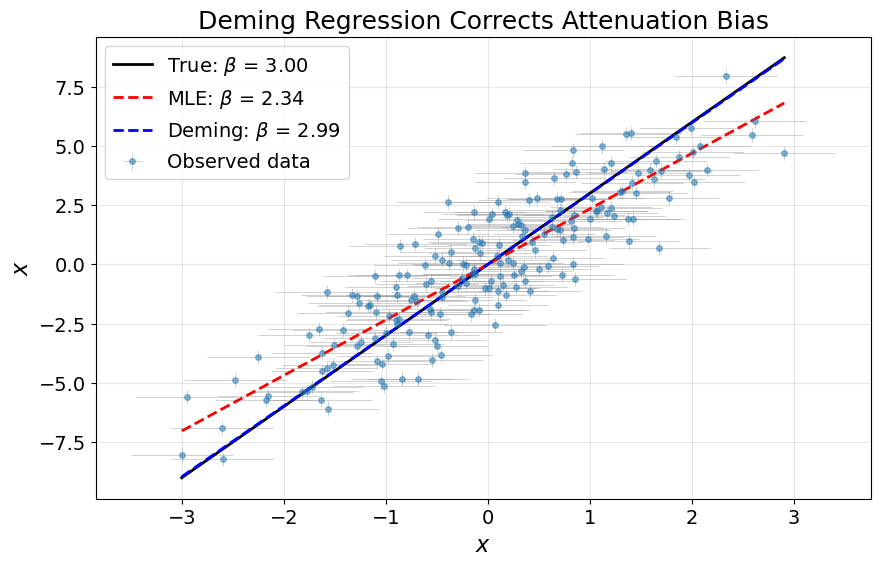

True slope:      3.000
MLE estimate:    2.342 (biased by -21.9%)
Deming estimate: 2.986 (biased by -0.5%)


In [34]:
# Test Deming regression on simulated data with known uncertainties
n_points = 200
true_slope = 3.0
x_range = 2.0
sigma_x = 0.5
sigma_y = 0.3

# Generate true values
x_true = np.random.normal(0, x_range/2, n_points)
y_true = true_slope * x_true

# Add measurement errors
x_obs = x_true + np.random.normal(0, sigma_x, n_points)
y_obs = y_true + np.random.normal(0, sigma_y, n_points)

# Center the observed data
x_centered = x_obs - np.mean(x_obs)
y_centered = y_obs - np.mean(y_obs)

# MLE (ignoring x-uncertainties)
beta_mle = np.sum(x_centered * y_centered) / np.sum(x_centered**2)

# Deming regression
Sxx = np.sum(x_centered**2)
Syy = np.sum(y_centered**2)
Sxy = np.sum(x_centered * y_centered)
lam = sigma_y**2 / sigma_x**2
beta_deming = (Syy - lam*Sxx + np.sqrt((Syy - lam*Sxx)**2 + 4*lam*Sxy**2)) / (2*Sxy)

# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.errorbar(x_centered, y_centered, xerr=sigma_x, yerr=sigma_y,
             fmt='o', markersize=4, alpha=0.5, ecolor='gray', 
             elinewidth=0.5, capsize=0, label='Observed data')

x_line = np.linspace(x_centered.min(), x_centered.max(), 100)
plt.plot(x_line, true_slope * x_line, 'k-', linewidth=2, 
         label=f'True: $\\beta$ = {true_slope:.2f}')
plt.plot(x_line, beta_mle * x_line, 'r--', linewidth=2,
         label=f'MLE: $\\beta$ = {beta_mle:.2f}')
plt.plot(x_line, beta_deming * x_line, 'b--', linewidth=2,
         label=f'Deming: $\\beta$ = {beta_deming:.2f}')

plt.xlabel('$x$')
plt.ylabel('$x$')
plt.title('Deming Regression Corrects Attenuation Bias')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"True slope:      {true_slope:.3f}")
print(f"MLE estimate:    {beta_mle:.3f} (biased by {100*(beta_mle-true_slope)/true_slope:.1f}%)")
print(f"Deming estimate: {beta_deming:.3f} (biased by {100*(beta_deming-true_slope)/true_slope:.1f}%)")

The results demonstrate that Deming regression successfully corrects most of the attenuation bias. While the MLE severely underestimates the slope, Deming regression recovers a value much closer to the truth. To determine whether the remaining difference from the true slope is within expected statistical variation, we'll use bootstrap resampling to quantify the uncertainty in our estimates:

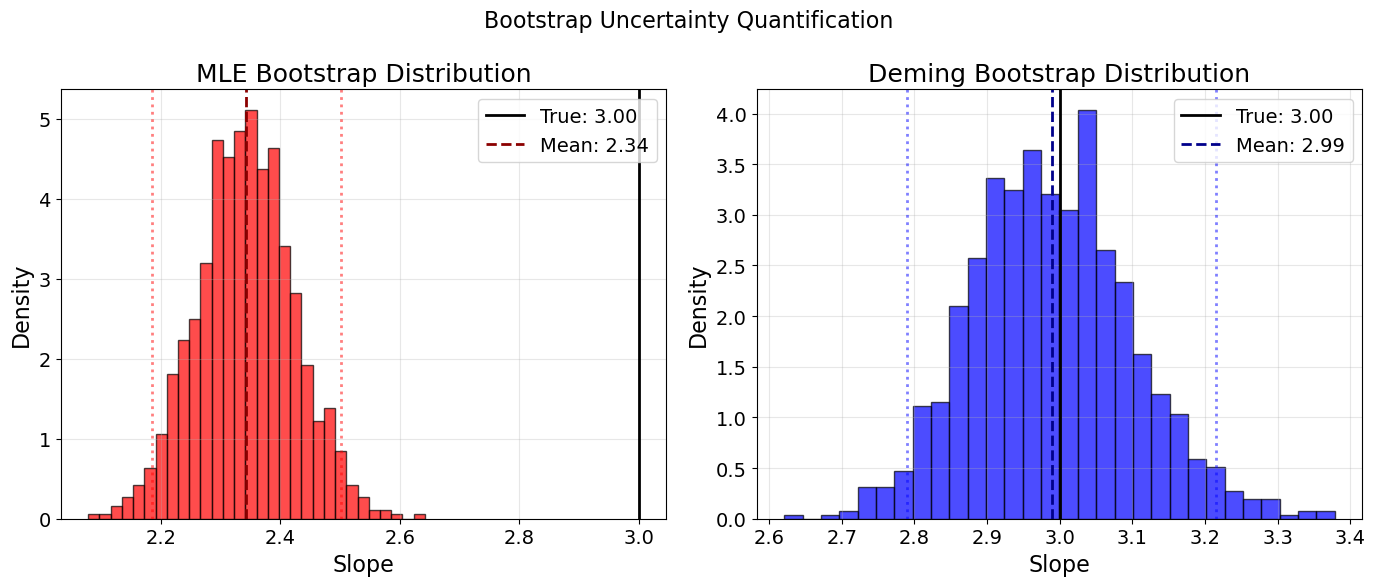

True slope: 3.000

MLE:
  Mean: 2.343
  95% CI: [2.185, 2.502]
  Contains true value: False

Deming:
  Mean: 2.989
  95% CI: [2.790, 3.216]
  Contains true value: True


In [35]:
# Bootstrap to quantify uncertainty in slope estimates
n_bootstrap = 1000
mle_slopes = []
deming_slopes = []

for _ in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(n_points, n_points, replace=True)
    x_boot = x_centered[idx]
    y_boot = y_centered[idx]
    
    # MLE estimate
    beta_mle_boot = np.sum(x_boot * y_boot) / np.sum(x_boot**2)
    mle_slopes.append(beta_mle_boot)
    
    # Deming estimate
    Sxx_boot = np.sum(x_boot**2)
    Syy_boot = np.sum(y_boot**2)
    Sxy_boot = np.sum(x_boot * y_boot)
    beta_deming_boot = (Syy_boot - lam*Sxx_boot + 
                        np.sqrt((Syy_boot - lam*Sxx_boot)**2 + 4*lam*Sxy_boot**2)) / (2*Sxy_boot)
    deming_slopes.append(beta_deming_boot)

mle_slopes = np.array(mle_slopes)
deming_slopes = np.array(deming_slopes)

# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# MLE distribution
ax1.hist(mle_slopes, bins=30, density=True, alpha=0.7, color='red', edgecolor='black')
ax1.axvline(true_slope, color='black', linestyle='-', linewidth=2, label=f'True: {true_slope:.2f}')
ax1.axvline(np.mean(mle_slopes), color='darkred', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(mle_slopes):.2f}')
ax1.axvline(np.percentile(mle_slopes, 2.5), color='red', linestyle=':', alpha=0.5)
ax1.axvline(np.percentile(mle_slopes, 97.5), color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Slope')
ax1.set_ylabel('Density')
ax1.set_title('MLE Bootstrap Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Deming distribution
ax2.hist(deming_slopes, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
ax2.axvline(true_slope, color='black', linestyle='-', linewidth=2, label=f'True: {true_slope:.2f}')
ax2.axvline(np.mean(deming_slopes), color='darkblue', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(deming_slopes):.2f}')
ax2.axvline(np.percentile(deming_slopes, 2.5), color='blue', linestyle=':', alpha=0.5)
ax2.axvline(np.percentile(deming_slopes, 97.5), color='blue', linestyle=':', alpha=0.5)
ax2.set_xlabel('Slope')
ax2.set_ylabel('Density')
ax2.set_title('Deming Bootstrap Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Bootstrap Uncertainty Quantification', fontsize=16)
plt.tight_layout()
plt.show()

# Print confidence intervals
mle_ci = np.percentile(mle_slopes, [2.5, 97.5])
deming_ci = np.percentile(deming_slopes, [2.5, 97.5])

print(f"True slope: {true_slope:.3f}\n")
print(f"MLE:")
print(f"  Mean: {np.mean(mle_slopes):.3f}")
print(f"  95% CI: [{mle_ci[0]:.3f}, {mle_ci[1]:.3f}]")
print(f"  Contains true value: {mle_ci[0] <= true_slope <= mle_ci[1]}\n")
print(f"Deming:")
print(f"  Mean: {np.mean(deming_slopes):.3f}")
print(f"  95% CI: [{deming_ci[0]:.3f}, {deming_ci[1]:.3f}]")
print(f"  Contains true value: {deming_ci[0] <= true_slope <= deming_ci[1]}")

The bootstrap analysis reveals a distinction between the two methods. The MLE distribution is centered far from the true value—the systematic bias from attenuation is much larger than the statistical uncertainty. In contrast, the Deming regression distribution encompasses the true slope within its confidence interval, confirming that the method successfully corrects for attenuation bias.

## Heteroscedastic Uncertainties: The Realistic Case

Our analysis so far assumed constant measurement uncertainties across all data points. However, real astronomical data rarely satisfies this assumption. In the SPARC dataset, brighter galaxies typically have more precise measurements than fainter ones, and different observational techniques yield different uncertainty levels.

For heteroscedastic (varying) uncertainties, the Deming regression framework extends naturally but loses its simple analytical form. Each data point's true $x$-value is estimated as:

$$x_{\text{true},i} = \frac{\sigma_{y,i}^2 x_{\text{obs},i} + \beta \sigma_{x,i}^2 x_{\text{obs},i}}{\sigma_{y,i}^2 + \beta^2 \sigma_{x,i}^2}$$

This is a weighted average between the observed $x$-value and the value inferred from $x$, with weights determined by the individual uncertainties. The slope $\beta$ must satisfy:

$$F(\beta) = \sum_i \frac{\sigma_{y,i}^2 x_{\text{obs},i} + \beta \sigma_{x,i}^2 x_{\text{obs},i}}{\sigma_{y,i}^2 + \beta^2 \sigma_{x,i}^2} (x_{\text{obs},i} - \beta x_{\text{obs},i}) = 0$$

Unlike the homoscedastic case, this equation doesn't reduce to a quadratic form. We must solve it numerically, but the computational cost is minimal since $F(\beta)$ is well-behaved with a single root. Let's demonstrate this on simulated data with varying uncertainties:

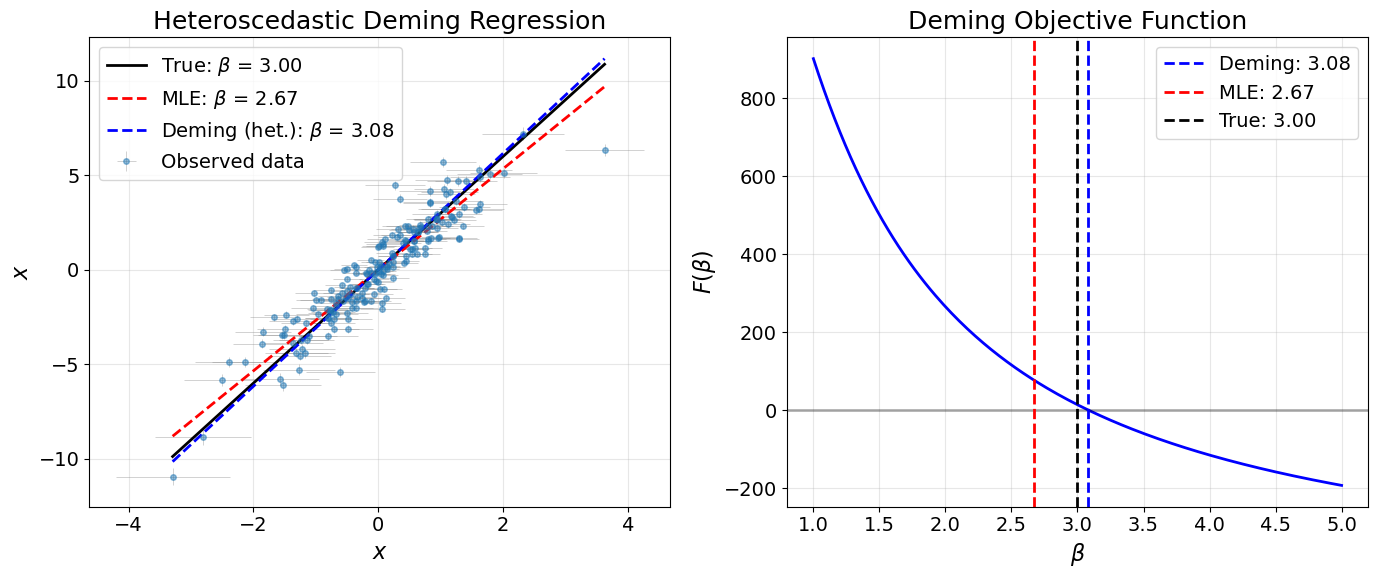

True slope:      3.000
MLE estimate:    2.674 (biased by -10.9%)
Deming (het.):   3.082 (biased by 2.7%)


In [36]:
# Simulate data with heteroscedastic uncertainties
n_points = 200
true_slope = 3.0
x_range = 2.0

# Generate true values
x_true = np.random.normal(0, x_range/2, n_points)
y_true = true_slope * x_true

# Create varying uncertainties - larger for points further from center
# This mimics real data where fainter/more distant objects have larger errors
sigma_x_het = 0.2 + 0.4 * np.abs(x_true) / x_range  # Ranges from 0.2 to 0.4
sigma_y_het = 0.1 + 0.2 * np.abs(x_true) / x_range  # Ranges from 0.1 to 0.2

# Add measurement errors with varying uncertainties
x_obs = x_true + np.random.normal(0, sigma_x_het)
y_obs = y_true + np.random.normal(0, sigma_y_het)

# Center the observed data
x_centered = x_obs - np.mean(x_obs)
y_centered = y_obs - np.mean(y_obs)
sigma_x_centered = sigma_x_het  # Uncertainties don't change with centering
sigma_y_centered = sigma_y_het

# MLE (ignoring x-uncertainties)
beta_mle = np.sum(x_centered * y_centered) / np.sum(x_centered**2)

# Heteroscedastic Deming regression - numerical solution
def deming_objective(beta):
    """Objective function F(β) for heteroscedastic Deming regression"""
    total = 0.0
    for i in range(n_points):
        numerator = sigma_y_centered[i]**2 * x_centered[i] + beta * sigma_x_centered[i]**2 * y_centered[i]
        denominator = sigma_y_centered[i]**2 + beta**2 * sigma_x_centered[i]**2
        total += (numerator / denominator) * (y_centered[i] - beta * x_centered[i])
    return total

# Find the root using Brent's method
beta_deming_het = brentq(deming_objective, 0.1, 10.0, xtol=1e-12, rtol=1e-12)

# Visualize
plt.figure(figsize=(14, 6))

# Left panel: Data with varying error bars
plt.subplot(1, 2, 1)
plt.errorbar(x_centered, y_centered, xerr=sigma_x_centered, yerr=sigma_y_centered,
             fmt='o', markersize=4, alpha=0.5, ecolor='gray', 
             elinewidth=0.5, capsize=0, label='Observed data')

x_line = np.linspace(x_centered.min(), x_centered.max(), 100)
plt.plot(x_line, true_slope * x_line, 'k-', linewidth=2, 
         label=f'True: $\\beta$ = {true_slope:.2f}')
plt.plot(x_line, beta_mle * x_line, 'r--', linewidth=2,
         label=f'MLE: $\\beta$ = {beta_mle:.2f}')
plt.plot(x_line, beta_deming_het * x_line, 'b--', linewidth=2,
         label=f'Deming (het.): $\\beta$ = {beta_deming_het:.2f}')

plt.xlabel('$x$')
plt.ylabel('$x$')
plt.title('Heteroscedastic Deming Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Right panel: Objective function
plt.subplot(1, 2, 2)
beta_range = np.linspace(1, 5, 200)
F_vals = [deming_objective(b) for b in beta_range]

plt.plot(beta_range, F_vals, 'b-', linewidth=2)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.axvline(beta_deming_het, color='b', linestyle='--', 
            label=f'Deming: {beta_deming_het:.2f}')
plt.axvline(beta_mle, color='r', linestyle='--', 
            label=f'MLE: {beta_mle:.2f}')
plt.axvline(true_slope, color='k', linestyle='--', 
            label=f'True: {true_slope:.2f}')

plt.xlabel('$\\beta$')
plt.ylabel('$F(\\beta)$')
plt.title('Deming Objective Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"True slope:      {true_slope:.3f}")
print(f"MLE estimate:    {beta_mle:.3f} (biased by {100*(beta_mle-true_slope)/true_slope:.1f}%)")
print(f"Deming (het.):   {beta_deming_het:.3f} (biased by {100*(beta_deming_het-true_slope)/true_slope:.1f}%)")

The heteroscedastic case successfully recovers the true slope even when uncertainties vary across the dataset. The right panel shows the objective function $F(\beta)$, which smoothly crosses zero at the Deming solution. The MLE, constrained to ignore $x$-uncertainties, remains biased regardless of whether those uncertainties are constant or varying.

## Forward vs Inverse Regression: A Common Confusion

Before applying Deming regression to the SPARC data, we need to address a common source of confusion in astronomical scaling relations. When fitting the Tully-Fisher relation, should we regress mass on velocity ($M$ vs $V$) or velocity on mass ($V$ vs $M$)? With standard MLE regression, these choices give different results that aren't simply reciprocals of each other.

This asymmetry arises because MLE minimizes residuals in only one direction. Forward regression ($V$ as $x$, $M$ as $x$) minimizes vertical residuals, while inverse regression ($M$ as $x$, $V$ as $x$) minimizes horizontal residuals. The choice matters because it implicitly assumes one variable is measured perfectly.

In the SPARC dataset, mass uncertainties (~0.5% relative) are much smaller than velocity uncertainties (~10% relative). From a statistical perspective, we should use mass as the independent variable since it's measured more precisely. However, astronomical convention plots velocity on the $x$-axis for the Tully-Fisher relation. This creates a dilemma: follow statistical best practices or astronomical conventions?

Deming regression resolves this tension by treating both variables symmetrically, accounting for uncertainties in both dimensions. The result is independent of which variable we label as $x$ or $x$—we get the same relationship either way. Let's demonstrate this with the SPARC data:

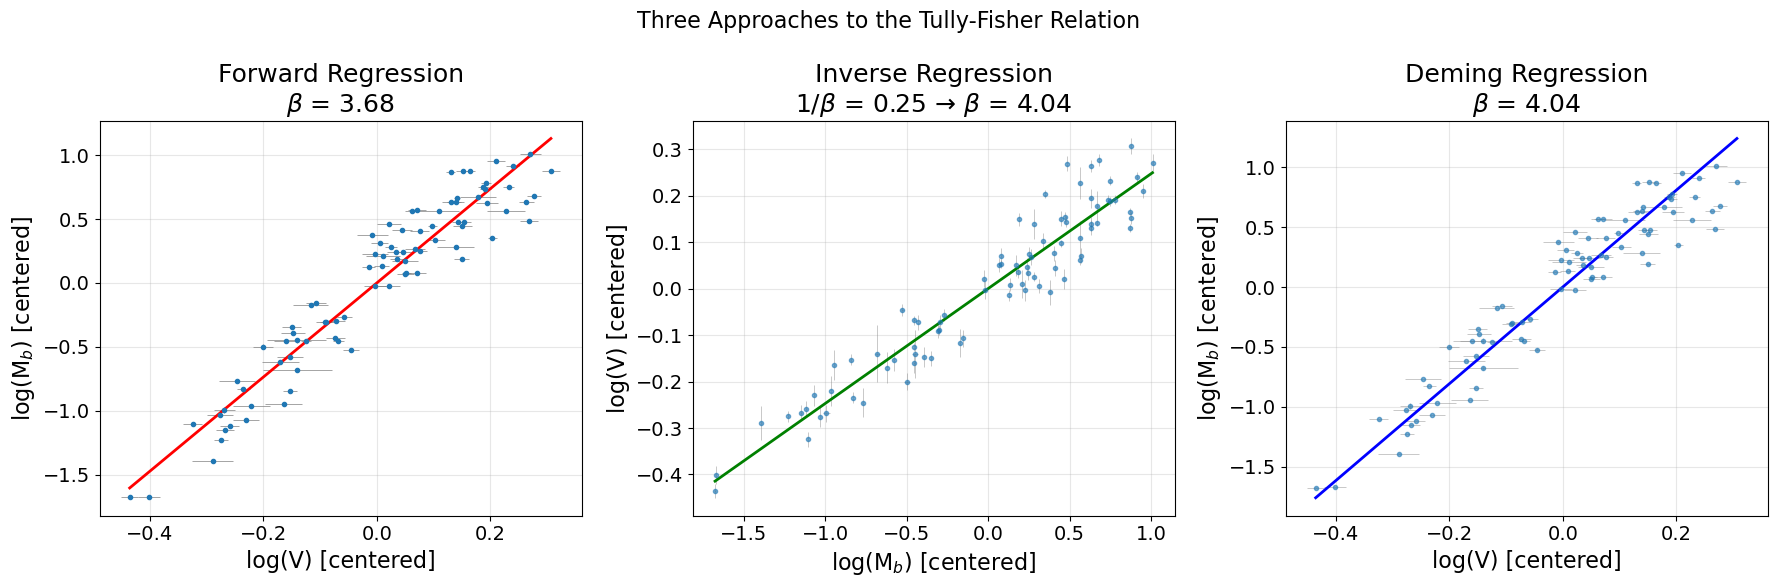

Forward regression (V→M):  β = 3.679
Inverse regression (M→V):  1/β = 0.247 → β = 4.043
Deming regression:         β = 4.041

Difference between forward and inverse: 0.365
Deming correction from forward: 0.363 (9.9%)


In [37]:
# Center the SPARC data
x_centered = logV - np.mean(logV)
y_centered = log_M_b - np.mean(log_M_b)

# Forward regression: V as x, M as y (astronomical convention)
beta_forward = np.sum(x_centered * y_centered) / np.sum(x_centered**2)

# Inverse regression: M as x, V as y (statistically preferred given uncertainties)
beta_inverse_raw = np.sum(x_centered * y_centered) / np.sum(y_centered**2)
# Convert to comparable slope (dM/dV) by taking reciprocal
beta_inverse = 1.0 / beta_inverse_raw

# Heteroscedastic Deming regression
def deming_objective_sparc(beta):
    """Objective function for SPARC data"""
    total = 0.0
    for i in range(len(x_centered)):
        numerator = e_log_M_b[i]**2 * x_centered[i] + beta * e_logV[i]**2 * y_centered[i]
        denominator = e_log_M_b[i]**2 + beta**2 * e_logV[i]**2
        total += (numerator / denominator) * (y_centered[i] - beta * x_centered[i])
    return total

# Find Deming solution
beta_deming = brentq(deming_objective_sparc, 1.0, 10.0, xtol=1e-12, rtol=1e-12)

# Visualize the different approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Forward regression plot
axes[0].errorbar(x_centered, y_centered, xerr=e_logV, yerr=e_log_M_b,
                 fmt='o', markersize=3, alpha=1.0, ecolor='gray', 
                 elinewidth=0.5, capsize=0)
x_line = np.linspace(x_centered.min(), x_centered.max(), 100)
axes[0].plot(x_line, beta_forward * x_line, 'r-', linewidth=2)
axes[0].set_xlabel('log(V) [centered]')
axes[0].set_ylabel('log(M$_b$) [centered]')
axes[0].set_title(f'Forward Regression\n$\\beta$ = {beta_forward:.2f}')
axes[0].grid(True, alpha=0.3)

# Inverse regression plot
axes[1].errorbar(y_centered, x_centered, xerr=e_log_M_b, yerr=e_logV,
                 fmt='o', markersize=3, alpha=0.6, ecolor='gray', 
                 elinewidth=0.5, capsize=0)
y_line = np.linspace(y_centered.min(), y_centered.max(), 100)
axes[1].plot(y_line, beta_inverse_raw * y_line, 'g-', linewidth=2)
axes[1].set_xlabel('log(M$_b$) [centered]')
axes[1].set_ylabel('log(V) [centered]')
axes[1].set_title(f'Inverse Regression\n1/$\\beta$ = {beta_inverse_raw:.2f} → $\\beta$ = {beta_inverse:.2f}')
axes[1].grid(True, alpha=0.3)

# Deming regression plot
axes[2].errorbar(x_centered, y_centered, xerr=e_logV, yerr=e_log_M_b,
                 fmt='o', markersize=3, alpha=0.6, ecolor='gray', 
                 elinewidth=0.5, capsize=0)
axes[2].plot(x_line, beta_deming * x_line, 'b-', linewidth=2)
axes[2].set_xlabel('log(V) [centered]')
axes[2].set_ylabel('log(M$_b$) [centered]')
axes[2].set_title(f'Deming Regression\n$\\beta$ = {beta_deming:.2f}')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Three Approaches to the Tully-Fisher Relation', fontsize=16)
plt.tight_layout()
plt.show()

print(f"Forward regression (V→M):  β = {beta_forward:.3f}")
print(f"Inverse regression (M→V):  1/β = {beta_inverse_raw:.3f} → β = {beta_inverse:.3f}")
print(f"Deming regression:         β = {beta_deming:.3f}")
print(f"\nDifference between forward and inverse: {abs(beta_forward - beta_inverse):.3f}")
print(f"Deming correction from forward: {beta_deming - beta_forward:.3f} ({100*(beta_deming - beta_forward)/beta_forward:.1f}%)")

The results reveal the practical importance of accounting for measurement uncertainties. The forward and inverse regressions differ by ~10%, demonstrating that the choice of dependent variable matters when using standard MLE. The Deming regression aligns closely with the inverse regression, and this is no coincidence—when one variable has much smaller uncertainties, Deming regression naturally weights it more heavily, effectively treating it as the independent variable.

In our case, with mass uncertainties (~0.5%) much smaller than velocity uncertainties (~10%), Deming regression recognizes that mass provides more reliable information. The method automatically gives us what we would get from a statistically optimal choice (inverse regression) while still allowing us to plot the data in the conventional way (velocity on the $\mathbf{x}$-axis).

The ~10% correction from forward to Deming regression appears larger than our simple theoretical prediction. With median velocity uncertainties at ~9% of the data range, the attenuation factor formula predicts:

$$\lambda \approx \frac{1}{1 + 0.1^2} \approx 0.99$$

This suggests only ~1% underestimation, yet we observe ~10% correction. This discrepancy arises from several factors:

**Distribution effects**: While the median relative uncertainty is ~10%, the distribution has a long tail. Galaxies with larger uncertainties contribute disproportionately to attenuation bias due to its nonlinear nature. Points with $\sigma_x/\sigma_{\text{range}} \approx 0.3$ can have $\lambda \approx 0.9$, creating much stronger attenuation.

**Observed versus intrinsic variance**: The formula requires $\sigma_{\text{range}}$ to be the standard deviation of the *true* velocities, but we calculate it from observed data that already includes measurement noise. The true intrinsic spread is:
$$\sigma^2_{\text{range,true}} \approx \sigma^2_{\text{range,obs}} - \text{median}(\sigma_x^2)$$

This makes the effective $\sigma_x/\sigma_{\text{range,true}}$ ratio larger than our naive calculation suggests, increasing the attenuation.

**Heteroscedastic effects**: The simple attenuation formula assumes homoscedastic errors. With heteroscedastic uncertainties, as in SPARC, the effective attenuation depends on how uncertainties correlate with the data distribution. If galaxies with larger uncertainties cluster in certain regions, they can bias the slope more than the theoretical prediction for homoscedastic errors would suggest.


## Bootstrap Uncertainty for the Tully-Fisher Relation

To quantify the uncertainty in our slope estimates and confirm that the difference between methods is statistically meaningful, we'll use bootstrap resampling on the SPARC data:

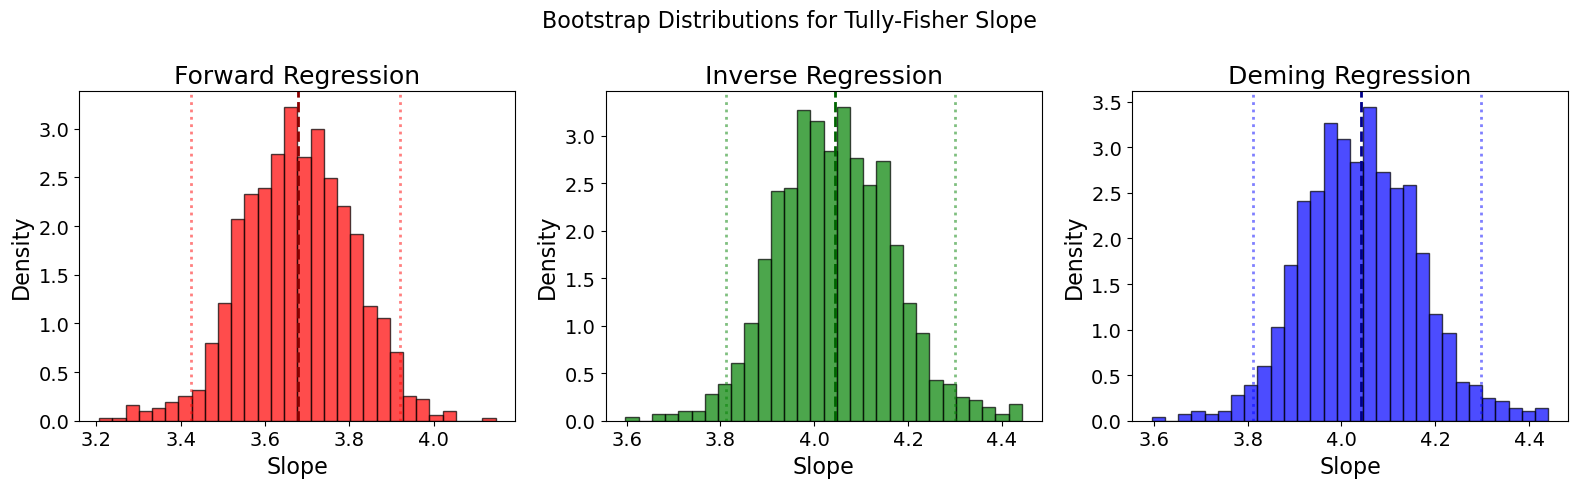

Tully-Fisher Slope Estimates (95% CI):
Forward:  3.679 [3.424, 3.921]
Inverse:  4.043 [3.812, 4.300]
Deming:   4.041 [3.810, 4.298]

Standard errors:
Forward:  0.130
Inverse:  0.123
Deming:   0.123


In [38]:
# Bootstrap to quantify uncertainty in SPARC slope estimates
n_bootstrap = 1000
n_galaxies = len(logV)

forward_slopes = []
inverse_slopes = []
deming_slopes = []

for _ in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(n_galaxies, n_galaxies, replace=True)
    
    # Get resampled data
    x_boot = x_centered[idx]
    y_boot = y_centered[idx]
    e_x_boot = e_logV[idx]
    e_y_boot = e_log_M_b[idx]
    
    # Forward regression
    beta_forward_boot = np.sum(x_boot * y_boot) / np.sum(x_boot**2)
    forward_slopes.append(beta_forward_boot)
    
    # Inverse regression
    beta_inverse_raw_boot = np.sum(x_boot * y_boot) / np.sum(y_boot**2)
    inverse_slopes.append(1.0 / beta_inverse_raw_boot)
    
    # Deming regression
    def deming_obj_boot(beta):
        total = 0.0
        for i in range(n_galaxies):
            numerator = e_y_boot[i]**2 * x_boot[i] + beta * e_x_boot[i]**2 * y_boot[i]
            denominator = e_y_boot[i]**2 + beta**2 * e_x_boot[i]**2
            total += (numerator / denominator) * (y_boot[i] - beta * x_boot[i])
        return total
    
    try:
        beta_deming_boot = brentq(deming_obj_boot, 1.0, 10.0)
        deming_slopes.append(beta_deming_boot)
    except:
        pass  # Skip if optimization fails

# Convert to arrays
forward_slopes = np.array(forward_slopes)
inverse_slopes = np.array(inverse_slopes)
deming_slopes = np.array(deming_slopes)

# Calculate confidence intervals
forward_ci = np.percentile(forward_slopes, [2.5, 97.5])
inverse_ci = np.percentile(inverse_slopes, [2.5, 97.5])
deming_ci = np.percentile(deming_slopes, [2.5, 97.5])

# Visualize bootstrap distributions
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.hist(forward_slopes, bins=30, density=True, alpha=0.7, color='red', edgecolor='black')
ax1.axvline(beta_forward, color='darkred', linestyle='--', linewidth=2)
ax1.axvline(forward_ci[0], color='red', linestyle=':', alpha=0.5)
ax1.axvline(forward_ci[1], color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Slope')
ax1.set_ylabel('Density')
ax1.set_title('Forward Regression')

ax2.hist(inverse_slopes, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(beta_inverse, color='darkgreen', linestyle='--', linewidth=2)
ax2.axvline(inverse_ci[0], color='green', linestyle=':', alpha=0.5)
ax2.axvline(inverse_ci[1], color='green', linestyle=':', alpha=0.5)
ax2.set_xlabel('Slope')
ax2.set_ylabel('Density')
ax2.set_title('Inverse Regression')

ax3.hist(deming_slopes, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
ax3.axvline(beta_deming, color='darkblue', linestyle='--', linewidth=2)
ax3.axvline(deming_ci[0], color='blue', linestyle=':', alpha=0.5)
ax3.axvline(deming_ci[1], color='blue', linestyle=':', alpha=0.5)
ax3.set_xlabel('Slope')
ax3.set_ylabel('Density')
ax3.set_title('Deming Regression')

plt.suptitle('Bootstrap Distributions for Tully-Fisher Slope', fontsize=16)
plt.tight_layout()
plt.show()

# Print results
print("Tully-Fisher Slope Estimates (95% CI):")
print(f"Forward:  {beta_forward:.3f} [{forward_ci[0]:.3f}, {forward_ci[1]:.3f}]")
print(f"Inverse:  {beta_inverse:.3f} [{inverse_ci[0]:.3f}, {inverse_ci[1]:.3f}]") 
print(f"Deming:   {beta_deming:.3f} [{deming_ci[0]:.3f}, {deming_ci[1]:.3f}]")
print(f"\nStandard errors:")
print(f"Forward:  {np.std(forward_slopes):.3f}")
print(f"Inverse:  {np.std(inverse_slopes):.3f}")
print(f"Deming:   {np.std(deming_slopes):.3f}")

The bootstrap analysis confirms that the differences between methods are statistically meaningful. The forward regression confidence interval doesn't overlap with either the inverse or Deming intervals. This ~10% difference in slope isn't just sample variance—it's a systematic bias from ignoring velocity uncertainties.

The near-identical results for inverse and Deming regression validate our theoretical understanding. When one variable has much smaller uncertainties (mass with ~0.5% vs velocity with ~10%), Deming regression effectively converges to treating the more precise variable as independent. The method automatically makes the statistically optimal choice while maintaining the flexibility to handle cases where both variables have comparable uncertainties.

The corrected Tully-Fisher slope has important astrophysical implications. The slope $\alpha \approx 4$ in the relation $M_b \propto V^\alpha$ tells us that galaxy mass scales with the fourth power of rotation velocity. This steep scaling has implications for our understanding of galaxy formation and dark matter.

A 10% underestimation of this slope would lead us to incorrect conclusions about how efficiently galaxies convert their baryons into stars as a function of halo mass. It would also bias distance measurements, since the Tully-Fisher relation serves as a rung in the cosmic distance ladder. The precise value of the slope constrains models of galaxy formation within dark matter halos, affecting our understanding of feedback processes and the relationship between baryonic and dark matter. By properly accounting for velocity uncertainties through Deming regression, we recover the true physical relationship that would otherwise be obscured by measurement errors. 

## Summary

This tutorial has demonstrated how measurement uncertainties in the independent variable lead to attenuation bias through the lens of the Tully-Fisher relation. We've explored several key concepts:

1. **Statistical Modeling**: Attenuation bias arises when measurement uncertainties in the independent variable artificially inflate the observed spread of data, systematically weakening measured relationships. The bias persists regardless of sample size and depends on the ratio of measurement uncertainty to intrinsic data spread.

2. **Parameter Estimation**: Deming regression corrects for attenuation bias by treating true values as latent variables to be inferred alongside model parameters. The method provides unbiased slope estimates when both variables have measurement uncertainties, naturally reducing to standard regression when uncertainties in $x$ approach zero.

3. **Practical Implementation**: For homoscedastic uncertainties, Deming regression has a closed-form solution. For heteroscedastic uncertainties common in astronomical data, numerical methods efficiently find the solution. Bootstrap resampling quantifies uncertainty in the corrected estimates.

4. **Astronomical Applications**: For the SPARC galaxy dataset, ignoring velocity uncertainties leads to a ~10% underestimation of the Tully-Fisher slope. This bias affects distance measurements, galaxy evolution studies, and our understanding of dark matter halos. Proper treatment of measurement uncertainties through techniques like Deming regression is essential for precision astronomy.

The techniques developed here apply whenever we measure relationships between quantities that both carry measurement uncertainties—a common situation in observational astronomy where perfect measurements remain elusive.


